In [74]:
from utils import *
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [75]:
def nice_solver_name(solver: str):
    if "AdditiveSchwarz" in solver:
        return "Additive"
    if "HybridSchwarz" in solver:
        return "Hybrid"
    return solver

In [76]:
dfs = []
for file in glob.glob("../results/experiment_parallelism*d2*f11*.csv"):
    dfs.append(pd.read_csv(file))
    print(file)
df = pd.concat(dfs, ignore_index=True)
df = process_experiments_df(df)

../results/experiment_parallelism_d2_p1_f11.csv


In [77]:
metadata_df = df.apply(extract_row_metadata, axis=1)
metadata_cols = metadata_df.columns.tolist()
df = pd.concat([df, metadata_df], axis=1)
df["solve time"] = df["solve times"].apply(safe_map(min))
df["solver"] = df["solver"].apply(nice_solver_name)
summary = df.pivot_table(
    index=["coarse m", "solvers m", "fine m"],
    columns="solver",
    values=metadata_cols,
    aggfunc="min",
)
summary

cg setup time                    cg time  \
solver                         Additive        Hybrid     Additive   
coarse m solvers m fine m                                            
C10      C10       S11      3334.576416   3605.732666   765.044495   
         C11       S11      3020.783203   3200.565430   777.115173   
         S10       S11      3196.618164   3961.809570   785.131592   
         S11       S11      3400.029541   3628.416016   871.918457   
C11      C11       S11      7090.609863   7448.796875  1458.170654   
         S11       S11      7736.833984   7871.378906  1559.600342   
C8       C10       S11      2175.683350   2294.004395   900.486206   
         C11       S11      1725.393799   2146.025146  1036.857056   
         S10       S11      1801.325317   2325.793945   948.789856   
         S11       S11      1717.958008   2483.757080  1327.575439   
         C9        S11      2275.187988           NaN  1123.389160   
         S9        S11      2185.169434   2488.337402   975.915588   
C9       C10       S11      1924.468140   2328.608643   685.877930   
         C11       S11      2226.995850   2463.969482   746.642700   
         S10       S11      2371.683594   2763.453613   696.378540   
         S11       S11      2250.625244   2769.207520   905.495667   
         C9        S11      2773.975098           NaN   881.920715   
         S9        S11      2514.373291   2961.398926   757.183350   
S10      S10       S11      4164.506836   5132.032715   972.484314   
         S11       S11      4564.649902   5197.145996  1117.580444   
S11      S11       S11     14126.904297  13272.306641  2416.946777   
S8       S10       S11      1736.045654   2323.279053   822.366638   
         S11       S11      1774.876221   2094.564209  1301.529785   
         S9        S11      2052.499512   2898.403320   838.517456   
S9       S10       S11      2246.052246   2519.495361   699.743469   
         S11       S11      2150.444580   2761.766602   864.420227   
         S9        S11      2220.173584   3048.397217   735.057556   

                                       coarse solver setup time                \
solver                          Hybrid                 Additive        Hybrid   
coarse m solvers m fine m                                                       
C10      C10       S11      425.208344              2468.531982   2455.480713   
         C11       S11      490.114899              2768.566162   2402.330811   
         S10       S11      514.082153              2219.208252   2421.994629   
         S11       S11      578.884827              2422.424072   2727.918701   
C11      C11       S11      724.193237              6126.093262   6326.326172   
         S11       S11      992.924866              5812.314453   6317.721191   
C8       C10       S11      673.965942              1388.386719   1409.176025   
         C11       S11      813.357788              1418.989868   1377.670898   
         S10       S11      755.539490              1154.535645   1342.448608   
         S11       S11      993.782837              1521.181763   1130.813721   
         C9        S11             NaN              1343.207520           NaN   
         S9        S11      708.467346              1147.834839   1379.660645   
C9       C10       S11      442.611237              1683.756836   1311.389648   
         C11       S11      531.386108              1353.353516   1683.529663   
         S10       S11      505.029663              1621.525269   1372.905884   
         S11       S11      634.602966              1391.589111   1362.071411   
         C9        S11             NaN              1682.563599           NaN   
         S9        S11      551.021912              1340.123047   1421.844727   
S10      S10       S11      648.803284              4109.801758   3627.387939   
         S11       S11      720.774719              3846.281250   3683.655518   
S11      S11       S11     1348.491821             13014.43847

In [78]:
def get_plot_df(coarse_m: int, solver: str):
    data = (
        summary.xs(coarse_m, level="coarse m")
        .xs(solver, level="solver", axis=1)
        .reset_index()
        .set_index("solvers m")
        .copy()
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    total_preconditioner_rest = "other preconditioner components"
    total_not_preconditioner = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_preconditioner_rest] = (
        data["preconditioner time"]
        - data["local solvers time"]
        - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_preconditioner] = (
        data["cg time"]
        - data[total_preconditioner_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[
            [
                total_not_preconditioner,
                total_preconditioner_rest,
                total_coarse_solver,
                total_local_solvers,
            ]
        ]
        / 1000
    )
    to_plot.sort_index(inplace=True, key=lambda x: x.map(mesh_to_key))
    to_plot.rename(index=lambda s: f"${format_mesh(s)}$", inplace=True)
    return to_plot

In [79]:
coarse_meshes = summary.index.get_level_values("coarse m").unique().to_list()
coarse_meshes.sort(key=mesh_to_key)
coarse_meshes

['C8', 'S8', 'C9', 'S9', 'C10', 'S10', 'C11', 'S11']

In [80]:
solvers = summary.columns.get_level_values("solver").unique().tolist()
solvers

['Additive', 'Hybrid']

Text(0.04, 0.94, '$\\mathcal{T}_\\mathcal{H}\\rightarrow$')

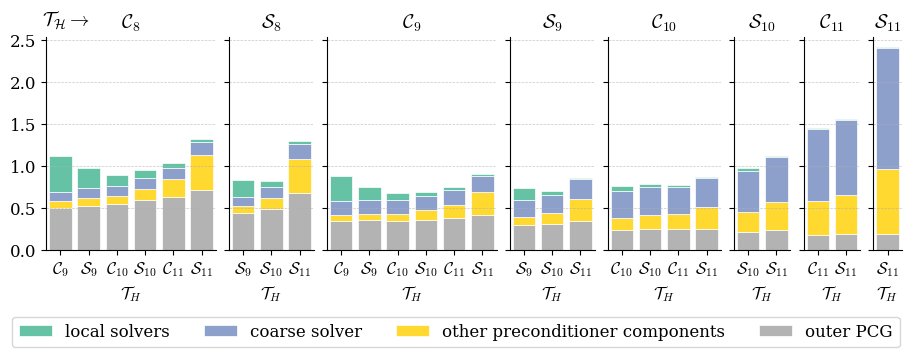

In [85]:
width_ratios = [
    len(summary.xs(cm, level="coarse m").index.get_level_values("solvers m").unique())
    for cm in coarse_meshes
]
fig, axes = plt.subplots(
    1,
    len(coarse_meshes),
    figsize=(9, 3),
    layout="constrained",
    sharey="row",
    width_ratios=width_ratios,
)
linthresh = 1
for ax, coarse_m in zip(axes.flat, coarse_meshes):
    plot_clustered_stacked(
        ax,
        [get_plot_df(coarse_m, solver) for solver in ["Additive"]],
        solvers,
        add_legend=False,
    )
    ax.set_title(f"${format_mesh(coarse_m)}$")
    ax.set_xlabel("$\\mathcal{{T}}_H$")
    if coarse_m == (8, "C"):
        ax.set_ylabel("solution time (s)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.0),
    ncols=4,
)
fig.text(0.04, 0.94, "$\\mathcal{T}_\\mathcal{H}\\rightarrow$", fontsize=14)

# fig.savefig("../docs/defence-media/inv_plots.svg", bbox_inches="tight")

## Setup times

In [82]:
local_solvers_setup_times = summary.pivot_table(
    index=["solvers m"], values=["local solvers setup time"]
)
local_solvers_setup_times

local solvers setup time            
solver                    Additive      Hybrid
solvers m                                     
C10                     417.498596  459.275441
C11                     315.156124  361.701172
C9                      836.734161         NaN
S10                     401.581045  461.665848
S11                     316.816401  306.557819
S9                      586.740067  714.350281

KeyError: 'Additive'

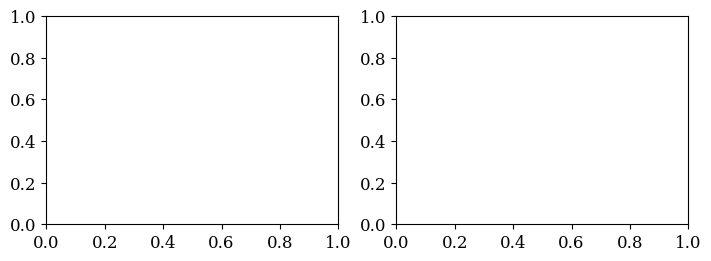

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5), layout="constrained")
for solver in solvers:
    ax = axes[1] if solver == "BatchCUDSS" else axes[0]
    data = local_solvers_setup_times.xs(solver, level="solver", axis=1) / 1000
    ax.scatter(
        range(len(data)),
        data.values,
        label=solver,
        marker=markers[solver],
        color=solver_colors.get(solver, "black"),
        facecolors="none",
    )
for i, ax in enumerate(axes):
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_xticks(range(len(local_solvers_setup_times.index)))
    ax.set_xticklabels(
        [f"${format_mesh(ms)}$" for ms in local_solvers_setup_times.index]
    )
    if i == 0:
        ax.set_ylabel("setup time (s)")
    ax.set_xlabel("$\\mathcal{T}_H$")
    if i == 1:
        ax.set_yscale("log")
fig.legend(loc="right", bbox_to_anchor=(1.25, 0.55), ncols=1)
fig.savefig("../docs/thesis-media/local_solvers_setup_times.svg", bbox_inches="tight")

In [ ]:
coarse_solver_setup_times = summary.pivot_table(
    index=["coarse m"], values=["coarse solver setup time"]
).min(axis=1)
coarse_solver_setup_times

coarse m
(8, C)       802.422119
(8, S)      1239.792236
(9, C)      1080.282959
(9, S)      2081.896667
(10, C)     1922.110107
(10, S)     3871.856934
(11, C)     5551.062988
(11, S)    11073.188477
dtype: float64

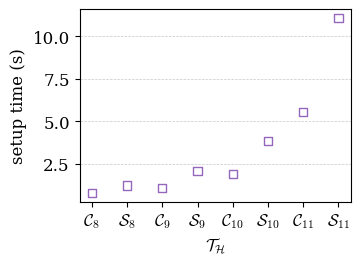

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.scatter(
    range(len(coarse_solver_setup_times)),
    coarse_solver_setup_times.values / 1000,
    marker=markers["BatchCUDSS"],
    edgecolors=solver_colors["BatchCUDSS"],
    facecolors="none",
)
ax.set_xticks(range(len(coarse_solver_setup_times.index)))
ax.set_xticklabels([f"${format_mesh(ms)}$" for ms in coarse_solver_setup_times.index])
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_ylabel("setup time (s)")
ax.set_xlabel("$\\mathcal{T}_\\mathcal{H}$")
fig.savefig("../docs/thesis-media/coarse_solver_setup_times.svg", bbox_inches="tight")